In [1]:
%load_ext watermark


In [2]:
import itertools as it
import os

import matplotlib as mpl
from matplotlib import pyplot as plt
import pandas as pd
from phyloframe import _auxlib as pfa
from phyloframe import legacy as pfl
from pyfonts import load_google_font
from teeplot import teeplot as tp

import pylib


/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/alifedata_phyloinformatics_convert/_impl/phytrack_Systematcs.py:7: UserWarning: ImportWarning: phylotrackpy.Systematics import failed; inserting a no-op mock for Systematics. This is likely because phylotrackpy is not installed.
  warnings.warn(


In [3]:
%watermark -diwmuv -iv


Last updated: 2026-03-23T17:53:30.976857+00:00

Python implementation: CPython
Python version       : 3.11.15
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

phyloframe: 0.6.1
matplotlib: 3.10.0
pandas    : 2.2.3
pylib     : 0.0.0
teeplot   : 1.4.2

Watermark: 2.4.3



In [4]:
teeplot_subdir = os.environ.get("NOTEBOOK_NAME", "2026-03-12-btr-foliage")
teeplot_subdir


'2026-03-12-btr-foliage'

In [5]:
pfa.seed_random(1)


In [6]:
font = load_google_font("Merriweather", weight=300)
mpl.font_manager.fontManager.addfont(font.get_file())
plt.rcParams["font.family"] = font.get_name()


## Prep Data


In [7]:
df_pure = pfl.alifestd_join_roots(
    pd.read_parquet("https://osf.io/vjhgs/download"),
)
df_pure


,id,dstream_data_id,ancestor_id,dstream_rank,hstrat_differentia_bitwidth,dstream_S,data_hex,bookend_left,bookend_right,bookend_value,...,CEREBRASLIB_HSTRAT_DSTREAM_ALGO_NAME,ASYNC_GA_GENOME_FLAVOR,is_extant,layer,layer_T,position,origin_time,hstrat_rank,is_root,is_oldest_root
0,0,NaN,0,NaN,NaN,NaN,None,NaN,NaN,NaN,...,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,True,True
1,1,NaN,0,NaN,NaN,NaN,None,NaN,NaN,NaN,...,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,False,False
2,2,NaN,0,190.0,1.0,96.0,None,NaN,NaN,NaN,...,NaN,NaN,None,NaN,NaN,NaN,94.0,94.0,False,False
3,3,NaN,2,382.0,1.0,96.0,None,NaN,NaN,NaN,...,NaN,NaN,None,NaN,NaN,NaN,286.0,286.0,False,False
4,4,NaN,3,574.0,1.0,96.0,None,NaN,NaN,NaN,...,NaN,NaN,None,NaN,NaN,NaN,478.0,478.0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99967,99967,1.009251e+09,98534,76091.0,1.0,96.0,bfb55c1e04a4f29ed05252d84bd80b3ad6a627d1,38682658.0,38682658.0,38682658.0,...,hybrid_0_steady_2_tilted_3_algo,genome_purifyingonly,False,1247.0,11297.0,151104.0,75995.0,75995.0,False,False
99968,99968,1.009495e+09,97878,76091.0,1.0,96.0,bfb5e23304a4f0f3d05252d81fd0f33f98b78d92,101105698.0,101105698.0,101105698.0,...,hybrid_0_steady_2_tilted_3_algo,genome_purifyingonly,False,1247.0,11297.0,394944.0,75995.0,75995.0,False,False
99969,99969,1.009207e+09,99869,76092.0,1.0,96.0,bfb5a2fa04a4f467d05252d84bd80b3a9c269853,27290658.0,27290658.0,27290658.0,...,hybrid_0_steady_2_tilted_3_algo,genome_purifyingonly,False,1247.0,11297.0,106604.0,75996.0,75996.0,False,False
99970,99970,1.009227e+09,99713,76093.0,1.0,96.0,bfb503e404a4f8c7d04253d84ad8ca3a7f468ed1,32388386.0,32388386.0,32388386.0,...,hybrid_0_steady_2_tilted_3_algo,genome_purifyingonly,False,1247.0,11297.0,126517.0,75997.0,75997.0,False,False


In [8]:
df_sweep = pfl.alifestd_join_roots(
    pd.read_parquet("https://osf.io/download/ajdsz"),
)
df_sweep


,id,dstream_data_id,ancestor_id,dstream_rank,hstrat_differentia_bitwidth,dstream_S,data_hex,bookend_left,bookend_right,bookend_value,...,CEREBRASLIB_HSTRAT_DSTREAM_ALGO_NAME,ASYNC_GA_GENOME_FLAVOR,is_extant,layer,layer_T,position,origin_time,hstrat_rank,is_root,is_oldest_root
0,0,NaN,0,NaN,NaN,NaN,None,NaN,NaN,NaN,...,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,True,True
1,1,NaN,0,NaN,NaN,NaN,None,NaN,NaN,NaN,...,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,False,False
2,2,NaN,0,766.0,1.0,96.0,None,NaN,NaN,NaN,...,NaN,NaN,None,NaN,NaN,NaN,670.0,670.0,False,False
3,3,NaN,2,1150.0,1.0,96.0,None,NaN,NaN,NaN,...,NaN,NaN,None,NaN,NaN,NaN,1054.0,1054.0,False,False
4,4,NaN,3,1534.0,1.0,96.0,None,NaN,NaN,NaN,...,NaN,NaN,None,NaN,NaN,NaN,1438.0,1438.0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99960,99960,1.009520e+09,99381,76063.0,1.0,96.0,7f7eff7304a4817b1fb1bf7f0be5f7eab61a22e0,107081138.0,107081138.0,107081138.0,...,hybrid_0_steady_2_tilted_3_algo,genome_purifyingplus,False,1247.0,13233.0,418285.0,75967.0,75967.0,False,False
99961,99961,1.009544e+09,98320,76065.0,1.0,96.0,7f7e777c04a489671fb5bf7e4bed29e88a089941,113309618.0,113309618.0,113309618.0,...,hybrid_0_steady_2_tilted_3_algo,genome_purifyingplus,False,1247.0,13233.0,442615.0,75969.0,75969.0,False,False
99962,99962,1.009394e+09,95230,76066.0,1.0,96.0,7f7e6b8604a48d051f84b36f27fd1f1af62dec23,75053234.0,75053234.0,75053234.0,...,hybrid_0_steady_2_tilted_3_algo,genome_purifyingplus,False,1247.0,13233.0,293176.0,75970.0,75970.0,False,False
99963,99963,1.009488e+09,97934,76069.0,1.0,96.0,7f7f77ad04a498ec972b75560dc3019867bc18dc,99088050.0,99088050.0,99088050.0,...,hybrid_0_steady_2_tilted_3_algo,genome_purifyingplus,False,1247.0,13233.0,387062.0,75973.0,75973.0,False,False


In [9]:
dfs = []
for df in (df_pure, df_sweep):
    df["x"] = df["position"] // df["nCol"]
    df["x_"] = df["x"] / df["nRow"]
    df["y"] = df["position"] % df["nCol"]
    df["y_"] = df["y"] / df["nCol"]

    df["origin_time"] = df["dstream_rank"]

    dfs.append(df)

df_pure, df_sweep = dfs


In [10]:
pure_sample = pfl.alifestd_downsample_tips_asexual(
    df_pure, n_downsample=8_000
)
sweep_sample = pfl.alifestd_downsample_tips_asexual(
    df_sweep, n_downsample=8_000
)


/tmp/ipykernel_5546/889159537.py:1: DeprecationWarning: Call to deprecated function (or staticmethod) alifestd_downsample_tips_asexual. (Use alifestd_downsample_tips_uniform_asexual instead.) -- Deprecated since version 0.6.0.
  pure_sample = pfl.alifestd_downsample_tips_asexual(
/tmp/ipykernel_5546/889159537.py:4: DeprecationWarning: Call to deprecated function (or staticmethod) alifestd_downsample_tips_asexual. (Use alifestd_downsample_tips_uniform_asexual instead.) -- Deprecated since version 0.6.0.
  sweep_sample = pfl.alifestd_downsample_tips_asexual(


## Plot Layer Tree


teeplots/2026-03-12-btr-foliage/layout=vertical+regime=pure+s=1+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-12-btr-foliage/layout=vertical+regime=pure+s=1+viz=draw-ctree+x=x+y=y+ext=.png


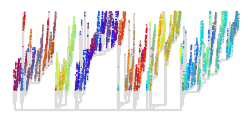

teeplots/2026-03-12-btr-foliage/layout=vertical+regime=sweep+s=1+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-12-btr-foliage/layout=vertical+regime=sweep+s=1+viz=draw-ctree+x=x+y=y+ext=.png


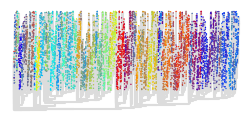

teeplots/2026-03-12-btr-foliage/layout=vertical+regime=pure+s=3+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-12-btr-foliage/layout=vertical+regime=pure+s=3+viz=draw-ctree+x=x+y=y+ext=.png


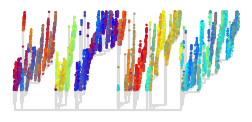

teeplots/2026-03-12-btr-foliage/layout=vertical+regime=sweep+s=3+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-12-btr-foliage/layout=vertical+regime=sweep+s=3+viz=draw-ctree+x=x+y=y+ext=.png


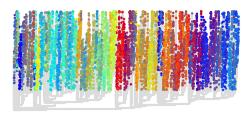

In [11]:
for s, regime, layout in it.product(
    (1, 3),
    ("pure", "sweep"),
    ("vertical",),
):
    df = {
        "pure": pure_sample,
        "sweep": sweep_sample,
    }[regime]
    with tp.teed(
        pylib.chloropleth.draw_ctree,
        df,
        x="x_",
        y="y_",
        cmap=pylib.cmap.bcyr.get_color,
        layout=layout,
        scatter_kws=dict(
            edgecolor="none",
            s=s,
        ),
        scatter_shuffle=1,
        tree_kws=dict(
            edge=dict(
                color="gainsboro",
                linewidth=0.5,
            ),
            margins=-0.05,
        ),
        teeplot_dpi=600,
        teeplot_outattrs={"regime": regime, "s": s},
        teeplot_subdir=teeplot_subdir,
    ) as teed:
        teed.invert_yaxis()
        teed.figure.set_size_inches(3, 1.33)


## Plot Fossil Scatterplot


teeplots/2026-03-12-btr-foliage/cmap=bcyr+regime=pure+viz=draw-cscatter+x=x+y=y+ext=.pdf
teeplots/2026-03-12-btr-foliage/cmap=bcyr+regime=pure+viz=draw-cscatter+x=x+y=y+ext=.png


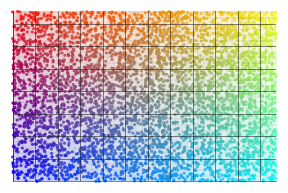

teeplots/2026-03-12-btr-foliage/cmap=bcyr+regime=sweep+viz=draw-cscatter+x=x+y=y+ext=.pdf
teeplots/2026-03-12-btr-foliage/cmap=bcyr+regime=sweep+viz=draw-cscatter+x=x+y=y+ext=.png


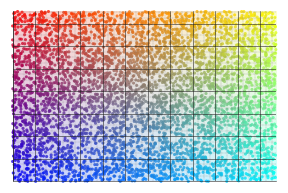

In [12]:
for regime in "pure", "sweep":
    df = {
        "pure": df_pure,
        "sweep": df_sweep,
    }[regime]
    with tp.teed(
        pylib.chloropleth.draw_cscatter,
        df.pipe(
            pfl.alifestd_downsample_tips_asexual, n_downsample=5_000, seed=1
        ).dropna(subset=["x_", "y_"]),
        x="x",
        y="y",
        cmap=pylib.cmap.bcyr.get_color,
        despine=True,
        major=100,
        minor=25,
        xmax=1170,
        ymax=755,
        scatter_kws=dict(
            alpha=0.8,
            s=5,
        ),
        teeplot_dpi=600,
        teeplot_outattrs={"cmap": "bcyr", "regime": regime},
        teeplot_subdir=teeplot_subdir,
    ) as teed:
        teed.set_aspect("equal")
        fig = teed.figure
        fig.set_size_inches(3, 2)
        fig.tight_layout()


## Combined Plots


teeplots/2026-03-12-btr-foliage/viz=subplots+ext=.pdf
teeplots/2026-03-12-btr-foliage/viz=subplots+ext=.png


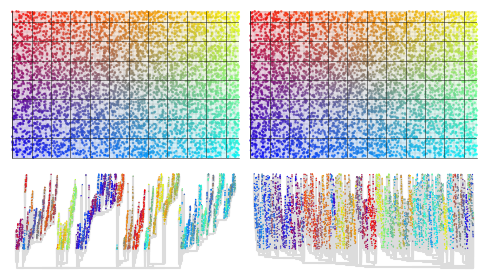

In [13]:
with tp.teed(
    plt.subplots,
    ncols=2,
    nrows=2,
    figsize=(6, 4),
    gridspec_kw={"height_ratios": [2, 1], "hspace": 0.1, "wspace": 0.05},
    teeplot_subdir=teeplot_subdir,
) as fig:
    fig, axs = fig

    for col, regime in enumerate(("pure", "sweep")):
        df = {
            "pure": df_pure,
            "sweep": df_sweep,
        }[regime]

        pylib.chloropleth.draw_cscatter(
            df.copy().pipe(
                pfl.alifestd_downsample_tips_asexual, n_downsample=5_000, seed=1
            ).dropna(subset=["x_", "y_"]),
            x="x",
            y="y",
            cmap=pylib.cmap.bcyr.get_color,
            despine=True,
            major=100,
            minor=25,
            scatter_kws=dict(
                alpha=0.8,
                s=3,
            ),
            xmax=1170,
            ymax=755,
            ax=axs[0, col],
        )
        axs[0, col].set_aspect("equal", anchor="S")

        pylib.chloropleth.draw_ctree(
            df.copy().pipe(
                pfl.alifestd_downsample_tips_asexual, n_downsample=5_000, seed=1
            ),
            x="x_",
            y="y_",
            cmap=pylib.cmap.bcyr.get_color,
            layout="vertical",
            scatter_kws=dict(
                edgecolor="none",
                s=1,
            ),
            scatter_shuffle=1,
            tree_kws=dict(
                edge=dict(
                    color="gainsboro",
                    linewidth=0.5,
                ),
                margins=-0.05,
            ),
            ax=axs[1, col],
        )
        if col == 1:
            axs[1, col].invert_xaxis()
        axs[1, col].invert_yaxis()
        axs[1, col].set_anchor("N")
